# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import joblib

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
X = df.drop(columns='dayofweek')
y = df.dayofweek

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [5]:
train_counts = y_train.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)
class_proportions = pd.DataFrame(data={'train': train_counts, 'test': test_counts})
class_proportions.sort_index()

,train,test
dayofweek,,
0,0.077893,0.091716
1,0.164688,0.153846
2,0.092730,0.071006
3,0.232196,0.245562
4,0.059347,0.071006
5,0.160237,0.162722
6,0.212908,0.204142


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)
train_counts = y_train.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)
class_proportions = pd.DataFrame(data={'train': train_counts, 'test': test_counts})
class_proportions.sort_index()

,train,test
dayofweek,,
0,0.080861,0.079882
1,0.162463,0.162722
2,0.088279,0.088757
3,0.234421,0.236686
4,0.061573,0.062130
5,0.160979,0.159763
6,0.211424,0.210059


## 2. Baseline models

### a. Logreg

In [7]:
logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
logreg_clf.fit(X_train, y_train)
logreg_accuracy = logreg_clf.score(X_test, y_test)
logreg_accuracy

0.6331360946745562

### b. SVM

In [8]:
svc_clf = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc_clf.fit(X_train, y_train)
svc_accuracy = svc_clf.score(X_test, y_test)
svc_accuracy

0.6301775147928994

### c. Decision tree

In [9]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_clf.fit(X_train, y_train)
tree_accuracy = tree_clf.score(X_test, y_test)
tree_accuracy

0.5295857988165681

### d. Random forest

In [10]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_clf.fit(X_train, y_train)
rf_accuracy = rf_clf.score(X_test, y_test)
rf_accuracy

0.9289940828402367

*answer 1: random forest*

## 3. Crossvalidation

In [11]:
def get_cv_accuracy_std(clf, X_train, y_train):
    scores = cross_val_score(clf, X_train, y_train, cv=10)
    mean_accuracy = scores.mean()
    std_accuracy = scores.std()
    return mean_accuracy, std_accuracy

### a. Logreg

In [12]:
logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
scores = cross_val_score(logreg_clf, X_train, y_train, cv=10)
logreg_accuracy = scores.mean()
logreg_accuracy

np.float64(0.6023880597014925)

In [13]:
logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
logreg_accuracy, logreg_std_accuracy = get_cv_accuracy_std(logreg_clf, X_train, y_train)
logreg_accuracy

np.float64(0.6023880597014925)

In [14]:
logreg_std_accuracy

np.float64(0.02852354077568261)

### b. SVM

In [15]:
svc_clf = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc_accuracy, svc_std_accuracy = get_cv_accuracy_std(svc_clf, X_train, y_train)
svc_accuracy

np.float64(0.5682918739635158)

In [16]:
svc_std_accuracy

np.float64(0.0372674056353565)

### c. Decision tree

In [17]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_accuracy, tree_std_accuracy = get_cv_accuracy_std(tree_clf, X_train, y_train)
tree_accuracy

np.float64(0.5088944168048645)

In [18]:
tree_std_accuracy

np.float64(0.031903139495514356)

### d. Random forest

In [19]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_accuracy, rf_std_accuracy = get_cv_accuracy_std(rf_clf, X_train, y_train)
rf_accuracy

np.float64(0.9176561636263129)

In [20]:
rf_std_accuracy

np.float64(0.02159583796321821)

## 4. Optimization

*We choose random forest as the best model*

In [21]:
parameters = {'max_depth': [1, 4, 10, 20, 40], 'n_estimators': [1, 5, 10, 20, 50, 100]}
rf = RandomForestClassifier(random_state=21)
grid_clf = GridSearchCV(rf, parameters)
grid_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=21)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 4, ...], 'n_estimators': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [22]:
final_accuracy = grid_clf.score(X_test, y_test)
final_accuracy

0.9289940828402367

In [23]:
def plot_feature_importances(coef, feature_names, top):
    # sum_coefs = np.abs(coef).sum(axis=0)
    feature_importances = pd.DataFrame(data={'feature_name': feature_names, 'importance': coef})
    feature_importances.sort_values('importance', ascending=False, inplace=True)

    fig, ax = plt.subplots()
    feature_importances.head(top).plot.barh(x='feature_name', y='importance', ax=ax, legend=False)
    ax.invert_yaxis()
    ax.set_xlabel('feature importance')
    ax.set_ylabel('feature name')
    plt.show()

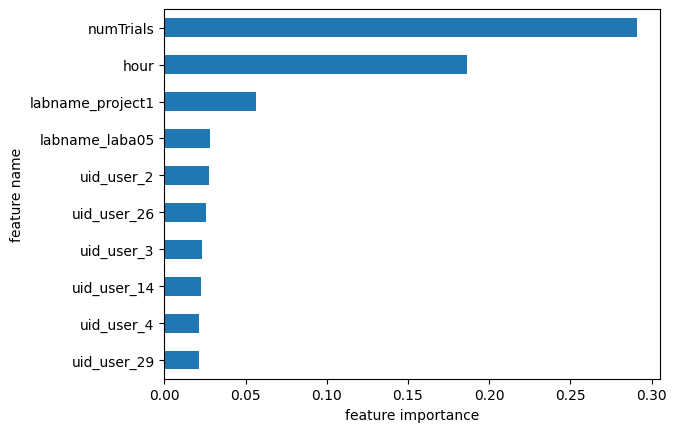

In [24]:
best_clf = grid_clf.best_estimator_
plot_feature_importances(coef=best_clf.feature_importances_, feature_names=X.columns, top=10)

In [25]:
filename = '../data/ex03_best_classifier.pkl'
joblib.dump(best_clf, filename)

['../data/ex03_best_classifier.pkl']

In [26]:
best_clf = joblib.load(filename)
y_test_predict = best_clf.predict(X_test)
final_accuracy = accuracy_score(y_test, y_test_predict)
final_accuracy

0.9289940828402367